In [32]:
# 1. ENVIRONMENT SETUP
import os, random, warnings
import numpy as np
import pandas as pd
import pmdarima as pm
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['PYTHONHASHSEED'] = '0'

# Deterministic execution
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

def mape_score(y_true, y_pred): 
    return np.mean(np.abs((np.array(y_true) - np.array(y_pred)) / np.array(y_true))) * 100

def dm_test(actual, pred1, pred2):
    e1, e2 = actual - pred1, actual - pred2
    d = e1**2 - e2**2
    gamma0 = np.var(d)
    if gamma0 == 0: return 0, 1
    stat = np.mean(d) / np.sqrt(gamma0 / len(d))
    return stat, 2 * (1 - norm.cdf(abs(stat)))


Optimal ARIMA Order: (2, 1, 2)


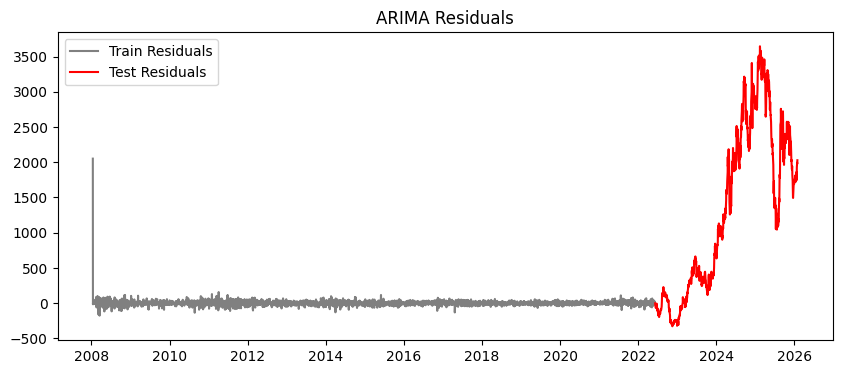

In [33]:
# 2. ARIMA MODELING
df = pd.read_csv('Data/Processed/Cleaned_Multivariate_Data.csv', index_col='Date', parse_dates=True)
features = ['Last Price', 'Volume', 'USD_Index', 'EFFR', 'Crude_Oil']
df = df[features]

train_size = int(len(df) * 0.8)
train_df, test_df = df.iloc[:train_size].copy(), df.iloc[train_size:].copy()
target_train, target_test = train_df['Last Price'], test_df['Last Price']

# Fit ARIMA
arima_model = pm.auto_arima(target_train, max_p=5, max_q=5, stepwise=True, suppress_warnings=True)
print(f"Optimal ARIMA Order: {arima_model.order}")

train_df['ARIMA_Pred'] = arima_model.predict_in_sample()
train_df['Residuals'] = target_train - train_df['ARIMA_Pred']
test_df['ARIMA_Pred'] = arima_model.predict(n_periods=len(target_test)).values
test_df['Residuals'] = target_test - test_df['ARIMA_Pred']

# Output: Residuals distribution
plt.figure(figsize=(10, 4))
plt.plot(train_df.index, train_df['Residuals'], label='Train Residuals', color='gray')
plt.plot(test_df.index, test_df['Residuals'], label='Test Residuals', color='red')
plt.title("ARIMA Residuals")
plt.legend()
plt.show()

In [34]:
# 3. DATA SCALING AND SEQUENCE GENERATION
time_steps = 60
nn_features = ['Residuals', 'Volume', 'USD_Index', 'EFFR', 'Crude_Oil']
std_features = ['Last Price', 'Volume', 'USD_Index', 'EFFR', 'Crude_Oil']

scaler_X_res, scaler_y_res = MinMaxScaler(), MinMaxScaler()
scaler_X_std, scaler_y_std = MinMaxScaler(), MinMaxScaler()

# 1. Tensors for Hybrid models (Target: Residuals)
X_train_res = scaler_X_res.fit_transform(train_df[nn_features])
y_train_res = scaler_y_res.fit_transform(train_df[['Residuals']])
X_test_res = scaler_X_res.transform(test_df[nn_features])
y_test_res = scaler_y_res.transform(test_df[['Residuals']])

# 2. Tensors for Standalone models (Target: Last Price)
X_train_std = scaler_X_std.fit_transform(train_df[std_features])
y_train_std = scaler_y_std.fit_transform(train_df[['Last Price']])
X_test_std = scaler_X_std.transform(test_df[std_features])
y_test_std = scaler_y_std.transform(test_df[['Last Price']])

def create_sequences(X, y, time_steps):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

X_train_seq_res, y_train_seq_res = create_sequences(X_train_res, y_train_res, time_steps)
X_test_seq_res, y_test_seq_res = create_sequences(X_test_res, y_test_res, time_steps)

X_train_seq_std, y_train_seq_std = create_sequences(X_train_std, y_train_std, time_steps)
X_test_seq_std, y_test_seq_std = create_sequences(X_test_std, y_test_std, time_steps)

print(f"Hybrid Tensors -> X_train: {X_train_seq_res.shape}, y_train: {y_train_seq_res.shape}")
print(f"Standalone Tensors -> X_train: {X_train_seq_std.shape}, y_train: {y_train_seq_std.shape}")



Hybrid Tensors -> X_train: (3622, 60, 5), y_train: (3622, 1)
Standalone Tensors -> X_train: (3622, 60, 5), y_train: (3622, 1)


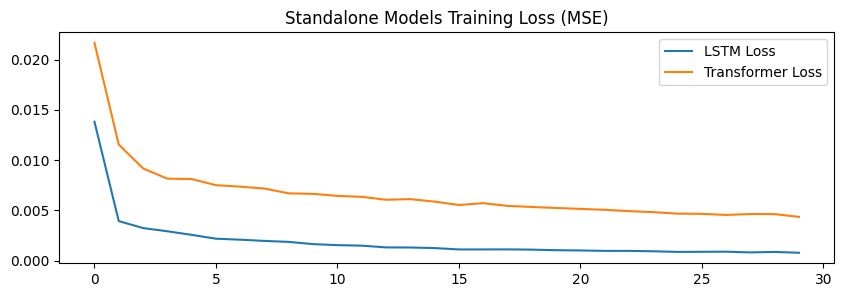

In [35]:
# 4. STANDALONE BASELINES 
input_shape = (X_train_seq_std.shape[1], X_train_seq_std.shape[2])

# LSTM Standalone
lstm_std = Sequential([
    LSTM(64, return_sequences=True, input_shape=input_shape), Dropout(0.2),
    LSTM(32, return_sequences=False), Dropout(0.2),
    Dense(16, activation='relu'), Dense(1)
])
lstm_std.compile(optimizer='adam', loss='mse')
hist_lstm_std = lstm_std.fit(X_train_seq_std, y_train_seq_std, epochs=30, batch_size=32, validation_split=0.1, verbose=0)

# Transformer Architecture
def build_transformer(input_shape):
    inputs = Input(shape=input_shape)
    x = MultiHeadAttention(num_heads=4, key_dim=64)(inputs, inputs)
    x = Dropout(0.2)(x)
    out1 = LayerNormalization(epsilon=1e-6)(inputs + x)
    x = Dense(128, activation="relu")(out1)
    x = Dense(input_shape[-1])(x)
    x = Dropout(0.2)(x)
    out2 = LayerNormalization(epsilon=1e-6)(out1 + x)
    x = GlobalAveragePooling1D()(out2)
    x = Dense(64, activation="relu")(x)
    x = Dropout(0.2)(x)
    outputs = Dense(1)(x)
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='mse')
    return model

trans_std = build_transformer(input_shape)
hist_trans_std = trans_std.fit(X_train_seq_std, y_train_seq_std, epochs=30, batch_size=32, validation_split=0.1, verbose=0)

lstm_std_pred = scaler_y_std.inverse_transform(lstm_std.predict(X_test_seq_std, verbose=0)).flatten()
trans_std_pred = scaler_y_std.inverse_transform(trans_std.predict(X_test_seq_std, verbose=0)).flatten()

# Output: Training Loss
plt.figure(figsize=(10, 3))
plt.plot(hist_lstm_std.history['loss'], label='LSTM Loss')
plt.plot(hist_trans_std.history['loss'], label='Transformer Loss')
plt.title("Standalone Models Training Loss (MSE)")
plt.legend()
plt.show()

Hybrid input shape matches: (60, 5)


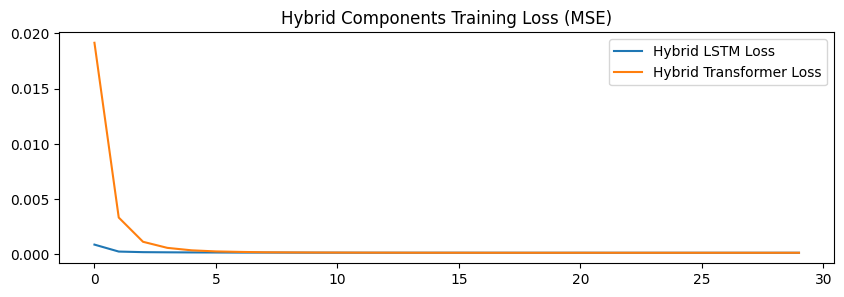

In [36]:
# 5.HYBRID COMPONENTS (TARGET: RESIDUALS)
# Verify hybrid input shape matches standalone (both use 4 features)
assert (X_train_seq_res.shape[1], X_train_seq_res.shape[2]) == input_shape, \
    "Mismatch between hybrid and standalone input shapes!"
print(f"Hybrid input shape matches: {input_shape}")

lstm_res = Sequential([
    LSTM(64, return_sequences=True, input_shape=input_shape), Dropout(0.2),
    LSTM(32, return_sequences=False), Dropout(0.2),
    Dense(16, activation='relu'), Dense(1)
])
lstm_res.compile(optimizer='adam', loss='mse')
hist_lstm_res = lstm_res.fit(X_train_seq_res, y_train_seq_res, epochs=30, batch_size=32, validation_split=0.1, verbose=0)

trans_res = build_transformer(input_shape)
hist_trans_res = trans_res.fit(X_train_seq_res, y_train_seq_res, epochs=30, batch_size=32, validation_split=0.1, verbose=0)

lstm_res_pred = scaler_y_res.inverse_transform(lstm_res.predict(X_test_seq_res, verbose=0)).flatten()
trans_res_pred = scaler_y_res.inverse_transform(trans_res.predict(X_test_seq_res, verbose=0)).flatten()

actual = target_test.values[time_steps:]
arima_base = test_df['ARIMA_Pred'].values[time_steps:]

# Y_t = L_t + N_t
hybrid_lstm = arima_base + lstm_res_pred
hybrid_trans = arima_base + trans_res_pred

# Output: Training Loss
plt.figure(figsize=(10, 3))
plt.plot(hist_lstm_res.history['loss'], label='Hybrid LSTM Loss')
plt.plot(hist_trans_res.history['loss'], label='Hybrid Transformer Loss')
plt.title("Hybrid Components Training Loss (MSE)")
plt.legend()
plt.show()

In [37]:
# 6. PERFORMANCE EVALUATION & STATISTICAL TESTING
results = []
models = {
    "ARIMA": arima_base,
    "LSTM (Standalone)": lstm_std_pred,
    "Transformer (Standalone)": trans_std_pred,
    "ARIMA-LSTM (Hybrid)": hybrid_lstm,
    "ARIMA-Transformer (Hybrid)": hybrid_trans
}

for name, pred in models.items():
    results.append({
        "Model": name,
        "MAE": round(mean_absolute_error(actual, pred), 2),
        "RMSE": round(np.sqrt(mean_squared_error(actual, pred)), 2),
        "MAPE (%)": round(mape_score(actual, pred), 2),
        "R2": round(r2_score(actual, pred), 4)
    })

results_df = pd.DataFrame(results).set_index("Model")
display(results_df)

# =============================================
# DIEBOLD-MARIANO TEST (Full Pairwise)
# H0: Model A and Model B have equivalent forecast accuracy
# DM < 0 & p < 0.05 => Model B significantly outperforms Model A
# =============================================
dm_pairs = [
    ("ARIMA",             "LSTM (Standalone)",          arima_base,   lstm_std_pred),
    ("ARIMA",             "ARIMA-LSTM (Hybrid)",         arima_base,   hybrid_lstm),
    ("ARIMA",             "ARIMA-Transformer (Hybrid)",  arima_base,   hybrid_trans),
    ("LSTM (Standalone)", "ARIMA-LSTM (Hybrid)",         lstm_std_pred, hybrid_lstm),
    ("LSTM (Standalone)", "Transformer (Standalone)",    lstm_std_pred, trans_std_pred),
]

dm_results = []
for name_a, name_b, pred_a, pred_b in dm_pairs:
    stat, p_val = dm_test(actual, pred_a, pred_b)
    dm_results.append({
        "Model A": name_a,
        "Model B": name_b,
        "DM Statistic": round(stat, 4),
        "p-value": round(p_val, 4),
        "Conclusion": "B outperforms A ***" if (stat > 0 and p_val < 0.05) else
                      "A outperforms B ***" if (stat < 0 and p_val < 0.05) else
                      "No significant difference"
    })

dm_df = pd.DataFrame(dm_results)
display(dm_df)

,MAE,RMSE,MAPE (%),R2
Model,,,,
ARIMA,1460.32,1834.38,34.86,-1.4774
LSTM (Standalone),406.62,536.41,9.49,0.7882
Transformer (Standalone),1090.39,1379.71,26.21,-0.4015
ARIMA-LSTM (Hybrid),1471.24,1851.08,35.08,-1.5227
ARIMA-Transformer (Hybrid),1486.20,1868.64,35.44,-1.5708


,Model A,Model B,DM Statistic,p-value,Conclusion
0,ARIMA,LSTM (Standalone),27.5680,0.0,B outperforms A ***
1,ARIMA,ARIMA-LSTM (Hybrid),-20.8857,0.0,A outperforms B ***
2,ARIMA,ARIMA-Transformer (Hybrid),-27.2020,0.0,A outperforms B ***
3,LSTM (Standalone),ARIMA-LSTM (Hybrid),-27.4236,0.0,A outperforms B ***
4,LSTM (Standalone),Transformer (Standalone),-25.0850,0.0,A outperforms B ***


In [ ]:
# 7. 7-DAY RECURSIVE FORECAST (STANDALONE LSTM)
print("Generating 7-day recursive forecast using optimal model (Standalone LSTM).")

future_steps = 7

# Take the last 60 days of the test set as the seed window (scaled 2D: n x features)
seed_window = X_test_std[-time_steps:].copy()  # shape: (60, 4)

future_price_scaled = []
current_window = seed_window.copy()

# Index of Last Price in std_features = ['Last Price', 'USD_Index', 'EFFR', 'Crude_Oil']
LP_IDX = std_features.index('Last Price')  # = 0

for step in range(future_steps):
    batch = current_window.reshape(1, time_steps, len(std_features))

    # pred_scaled: output in scaler_y_std space (Last Price only)
    pred_scaled = lstm_std.predict(batch, verbose=0)[0][0]
    future_price_scaled.append([[pred_scaled]])

    # Convert pred_scaled (scaler_y_std space) back to scaler_X_std space (column 0)
    # Safe approach: inverse scaler_y -> real price -> re-scale via scaler_X_std col 0
    price_real = scaler_y_std.inverse_transform([[pred_scaled]])[0][0]

    # Re-scale price_real into scaler_X_std space using data_min_ and data_range_
    price_in_X_space = (price_real - scaler_X_std.data_min_[LP_IDX]) / scaler_X_std.data_range_[LP_IDX]
    price_in_X_space = np.clip(price_in_X_space, 0, 1)  # keep within [0, 1]

    # Build new row: update Last Price, freeze macro variables (Ceteris Paribus)
    new_row = current_window[-1, :].copy()
    new_row[LP_IDX] = price_in_X_space

    # Slide the window forward
    current_window = np.vstack([current_window[1:], new_row])

# Decode to real prices
final_forecast = scaler_y_std.inverse_transform(
    np.array(future_price_scaled).reshape(-1, 1)
).flatten()

# 95% CI: use std of test residuals (more robust than homogeneous variance assumption)
test_residuals = actual - lstm_std_pred
margin = 1.96 * np.std(test_residuals)
lower_bound = final_forecast - margin
upper_bound = final_forecast + margin

forecast_df = pd.DataFrame({
    'Horizon': [f"T+{i+1}" for i in range(future_steps)],
    'Forecast (USD/Ton)': np.round(final_forecast, 2),
    'Risk Floor 95% (USD/Ton)': np.round(lower_bound, 2),
    'Risk Ceiling 95% (USD/Ton)': np.round(upper_bound, 2),
})

print("-" * 65)
print(forecast_df.to_string(index=False))
print("-" * 65)

# os.makedirs('reports', exist_ok=True)
# forecast_df.to_csv('reports/Future_7Days.csv', index=False)

Generating 7-day recursive forecast using optimal model (Standalone LSTM).
-----------------------------------------------------------------
Horizon  Forecast (USD/Ton)  Risk Floor 95% (USD/Ton)  Risk Ceiling 95% (USD/Ton)
    T+1         3640.469971                   2952.17                     4328.78
    T+2         3014.340088                   2326.03                     3702.65
    T+3         2711.110107                   2022.81                     3399.42
    T+4         2599.219971                   1910.91                     3287.53
    T+5         2542.479980                   1854.17                     3230.79
    T+6         2499.469971                   1811.16                     3187.78
    T+7         2455.209961                   1766.91                     3143.52
-----------------------------------------------------------------


In [39]:
os.makedirs('reports', exist_ok=True)
forecast_df.to_csv('reports/Future_7Days.csv', index=False)